# Bivariate Analysis

This notebook studies the relationship between key features and the fraud target. The goal is to identify which variables show meaningful separation between legitimate and fraudulent transactions and which relationships may improve model performance.

## 1. Objectives

This notebook focuses on the following tasks:

- compare important features across the fraud target classes
- study how `Amount` and `Time` behave for fraud and non-fraud transactions
- inspect class-wise feature distributions for selected PCA variables
- summarize which features show stronger separation from the target
- save bivariate tables, figures, and a markdown report for later modeling decisions

## Output Guide

- **Class-wise summary tables:** show how a feature behaves separately for legitimate and fraudulent transactions, helping assess whether the feature shifts meaningfully across the target.
- **Boxplots by class:** highlight differences in spread, median behavior, and extreme observations between the two classes.
- **Class-wise distribution plots:** help evaluate whether the fraud and non-fraud distributions overlap heavily or show useful separation.
- **Selected PCA feature summaries:** compare which transformed components appear more informative when grouped by class.
- **Correlation with target table:** provides a simple screening view of how strongly each feature is linearly associated with `Class`, though it should not be treated as a final feature-selection rule.
- **Top correlation chart:** helps prioritize which variables deserve more attention in multivariate analysis and model building.

The purpose of these outputs is to move from single-feature understanding to class-aware feature usefulness for fraud detection.

In [65]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import mannwhitneyu

sys.path.append(str(Path("..").resolve()))

from src.config import AMOUNT_COLUMN, PCA_COLUMNS, PROJECT_ROOT, TARGET_COLUMN, TIME_COLUMN
from src.data.data_loader import load_cleaned_data

NOTEBOOK_TABLES_DIR = PROJECT_ROOT / "reports" / "tables" / "06_bivariate_analysis"
NOTEBOOK_FIGURES_DIR = PROJECT_ROOT / "reports" / "figures" / "06_bivariate_analysis"
NOTEBOOK_TABLES_DIR.mkdir(parents=True, exist_ok=True)
NOTEBOOK_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")

print("Imports OK")
print(f"  Target column : {TARGET_COLUMN}")
print(f"  Tables dir    : {NOTEBOOK_TABLES_DIR}")
print(f"  Figures dir   : {NOTEBOOK_FIGURES_DIR}")

Imports OK
  Target column : Class
  Tables dir    : /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/reports/tables/06_bivariate_analysis
  Figures dir   : /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/reports/figures/06_bivariate_analysis


## 2. Load Cleaned Data

In [66]:
df = load_cleaned_data()

print("Cleaned dataset shape:", df.shape)
df.head()

Cleaned dataset shape: (283726, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 3. Amount vs Class

Because transaction `Amount` is heavily right-skewed, this section includes both raw-scale and `log1p`-transformed comparisons. The log-transformed view improves readability and makes class-wise differences easier to inspect without removing extreme transactions.


In [67]:
amount_by_class = df.groupby(TARGET_COLUMN)[AMOUNT_COLUMN].agg(["count", "mean", "median", "std", "min", "max"]).round(4)
amount_by_class.to_csv(NOTEBOOK_TABLES_DIR / "amount_by_class_summary.csv")
amount_by_class

,count,mean,median,std,min,max
Class,,,,,,
0,283253,88.4136,22.00,250.379,0.0,25691.16
1,473,123.8719,9.82,260.211,0.0,2125.87


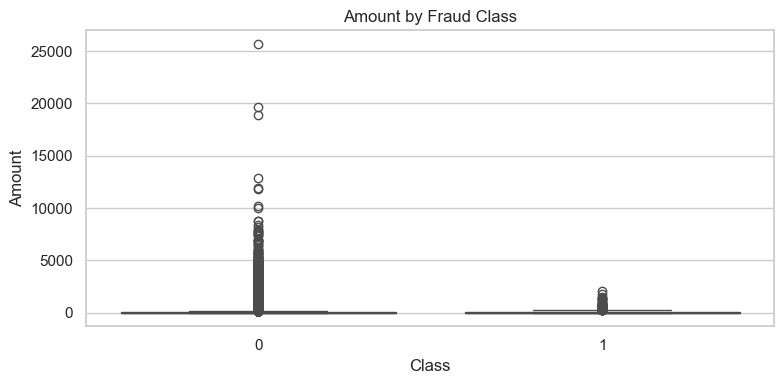

In [68]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x=TARGET_COLUMN, y=AMOUNT_COLUMN)
plt.title("Amount by Fraud Class")
plt.xlabel("Class")
plt.ylabel("Amount")
plt.tight_layout()
plt.savefig(NOTEBOOK_FIGURES_DIR / "amount_by_class_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

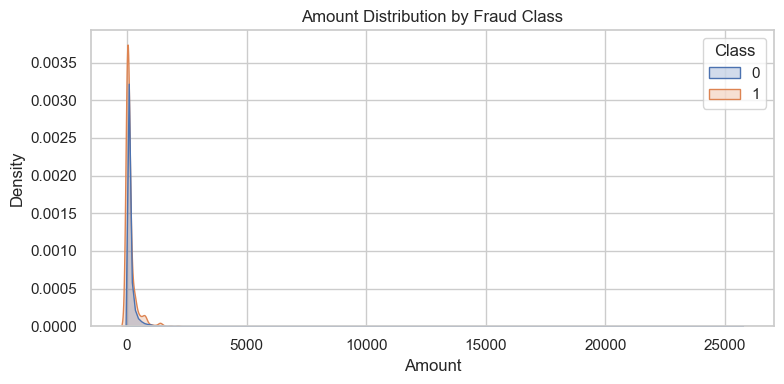

In [69]:
plt.figure(figsize=(8, 4))
sns.kdeplot(data=df, x=AMOUNT_COLUMN, hue=TARGET_COLUMN, common_norm=False, fill=True)
plt.title("Amount Distribution by Fraud Class")
plt.xlabel("Amount")
plt.ylabel("Density")
plt.tight_layout()
plt.savefig(NOTEBOOK_FIGURES_DIR / "amount_by_class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

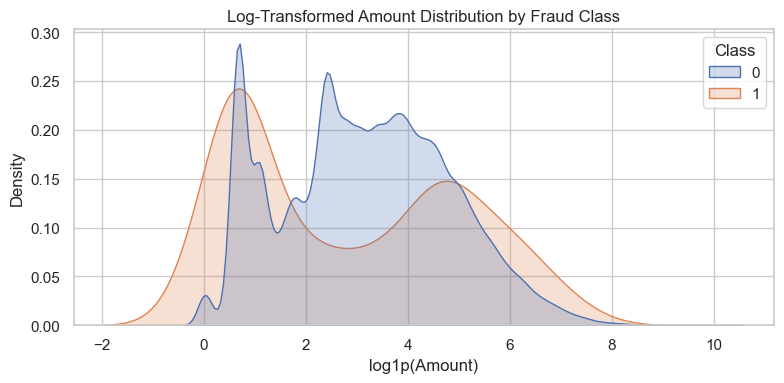

In [70]:
df_amount_log = df[[TARGET_COLUMN, AMOUNT_COLUMN]].copy()
df_amount_log["log_amount"] = np.log1p(df_amount_log[AMOUNT_COLUMN])

plt.figure(figsize=(8, 4))
sns.kdeplot(data=df_amount_log, x="log_amount", hue=TARGET_COLUMN, common_norm=False, fill=True)
plt.title("Log-Transformed Amount Distribution by Fraud Class")
plt.xlabel("log1p(Amount)")
plt.ylabel("Density")
plt.tight_layout()
plt.savefig(NOTEBOOK_FIGURES_DIR / "log_amount_by_class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


## 4. Time vs Class

In [71]:
time_by_class = df.groupby(TARGET_COLUMN)[TIME_COLUMN].agg(["count", "mean", "median", "std", "min", "max"]).round(4)
time_by_class.to_csv(NOTEBOOK_TABLES_DIR / "time_by_class_summary.csv")
time_by_class

,count,mean,median,std,min,max
Class,,,,,,
0,283253,94835.0581,84711.0,47475.5506,0.0,172792.0
1,473,80450.5137,73408.0,48636.1800,406.0,170348.0


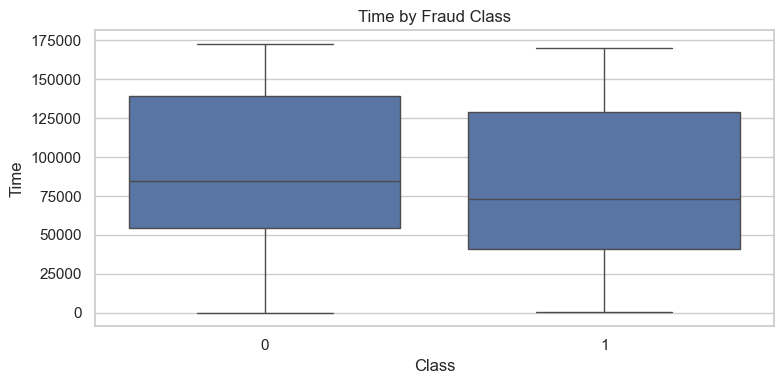

In [72]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x=TARGET_COLUMN, y=TIME_COLUMN)
plt.title("Time by Fraud Class")
plt.xlabel("Class")
plt.ylabel("Time")
plt.tight_layout()
plt.savefig(NOTEBOOK_FIGURES_DIR / "time_by_class_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

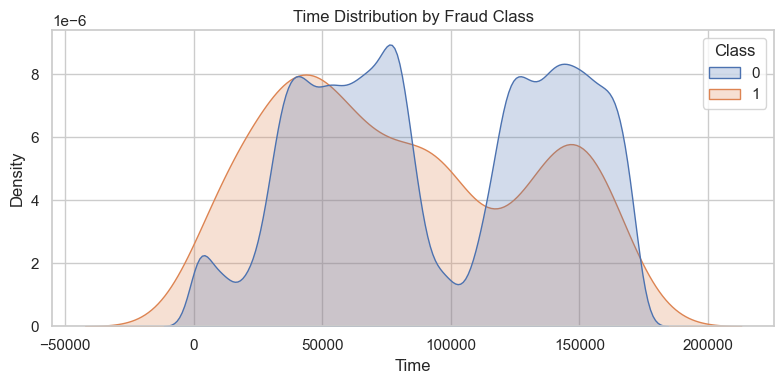

In [73]:
plt.figure(figsize=(8, 4))
sns.kdeplot(data=df, x=TIME_COLUMN, hue=TARGET_COLUMN, common_norm=False, fill=True)
plt.title("Time Distribution by Fraud Class")
plt.xlabel("Time")
plt.ylabel("Density")
plt.tight_layout()
plt.savefig(NOTEBOOK_FIGURES_DIR / "time_by_class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## 5. PCA Features vs Class

To keep the notebook readable while staying aligned with the later feature-priority results, this section visualizes the **top 6 PCA features by absolute correlation with the fraud class** rather than the first six PCA columns by position.


In [74]:
pca_correlations = df[[*PCA_COLUMNS, TARGET_COLUMN]].corr(numeric_only=True)[TARGET_COLUMN].drop(TARGET_COLUMN)
selected_pca_features = pca_correlations.abs().sort_values(ascending=False).head(6).index.tolist()
print("Top 6 PCA features selected for bivariate visualization:", selected_pca_features)

pca_class_summary_frames = []

for feature in selected_pca_features:
    summary = df.groupby(TARGET_COLUMN)[feature].agg(["mean", "median", "std"]).round(4)
    summary.insert(0, "feature", feature)
    summary.insert(1, "abs_correlation_with_class", round(abs(pca_correlations[feature]), 6))
    pca_class_summary_frames.append(summary.reset_index())

pca_class_summary = pd.concat(pca_class_summary_frames, ignore_index=True)
pca_class_summary.to_csv(NOTEBOOK_TABLES_DIR / "selected_pca_by_class_summary.csv", index=False)
pca_class_summary


Top 6 PCA features selected for bivariate visualization: ['V17', 'V14', 'V12', 'V10', 'V16', 'V3']


,Class,feature,abs_correlation_with_class,mean,median,std
0,0,V17,0.313498,0.0110,-0.0651,0.7485
1,1,V17,0.313498,-6.4633,-5.1576,6.9657
2,0,V14,0.293375,0.0117,0.0515,0.8944
3,1,V14,0.293375,-6.8359,-6.5906,4.2532
4,0,V12,0.250711,0.0095,0.1406,0.9454
5,1,V12,0.250711,-6.1033,-5.4374,4.5823
6,0,V10,0.206971,0.0077,-0.0921,1.0363
7,1,V10,0.206971,-5.4533,-4.4663,4.7065
8,0,V16,0.187186,0.0078,0.0681,0.8446
9,1,V16,0.187186,-4.0010,-3.3029,3.8317


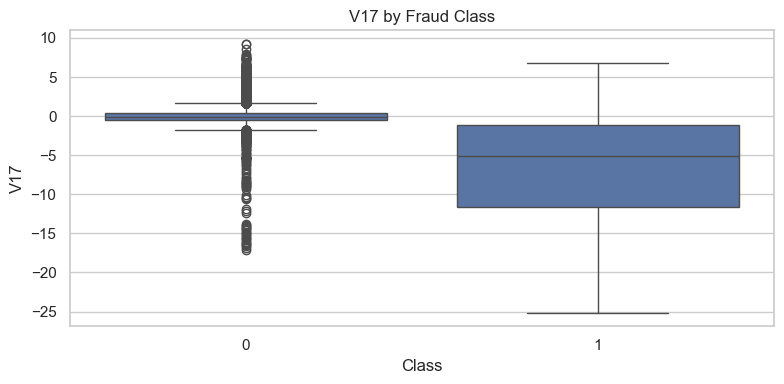

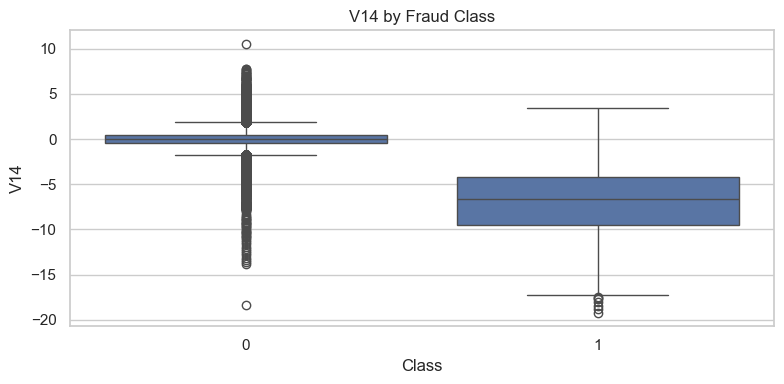

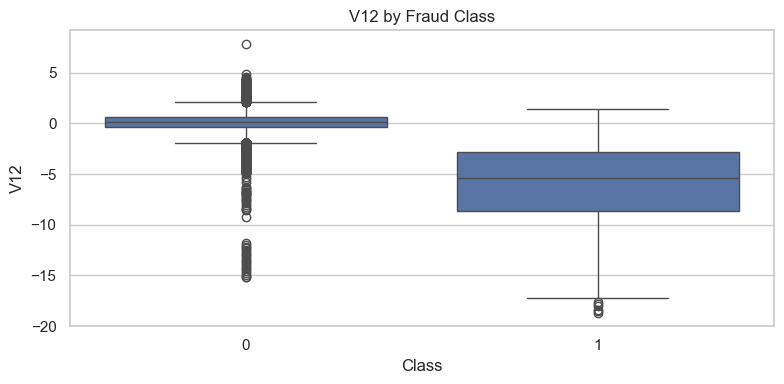

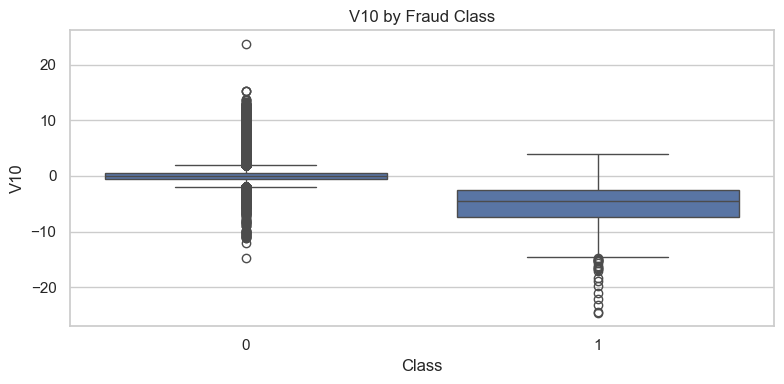

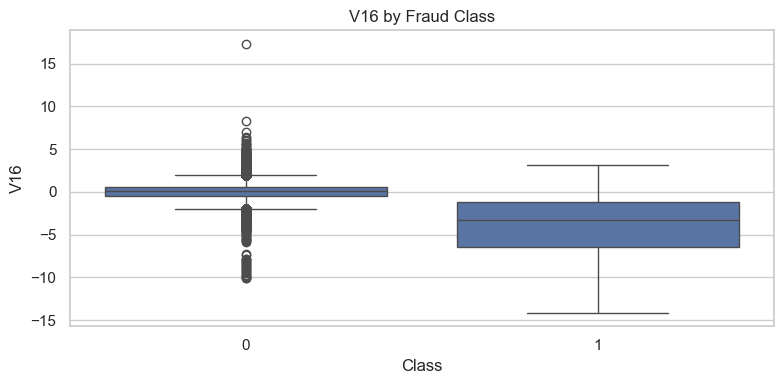

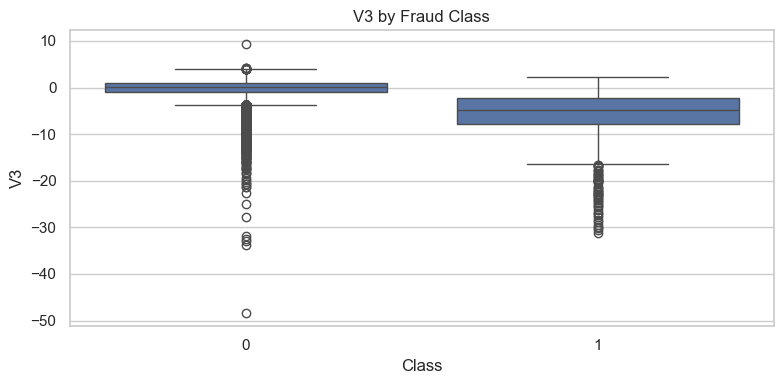

In [75]:
for feature in selected_pca_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x=TARGET_COLUMN, y=feature)
    plt.title(f"{feature} by Fraud Class")
    plt.xlabel("Class")
    plt.ylabel(feature)
    plt.tight_layout()
    plt.savefig(NOTEBOOK_FIGURES_DIR / f"{feature.lower()}_by_class_boxplot.png", dpi=300, bbox_inches="tight")
    plt.show()

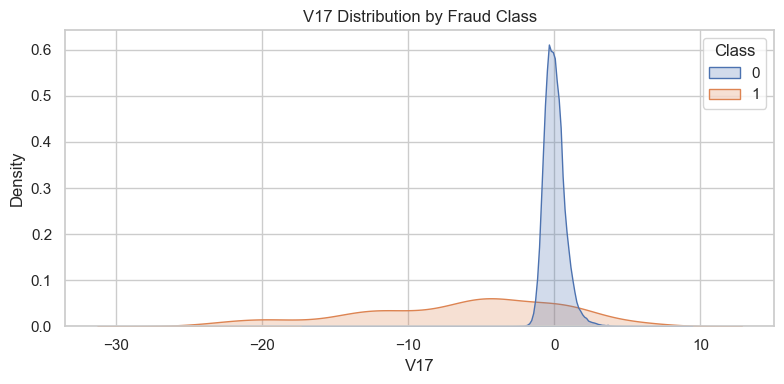

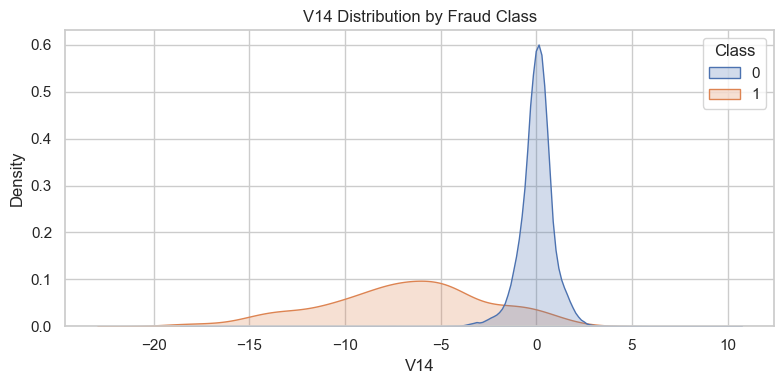

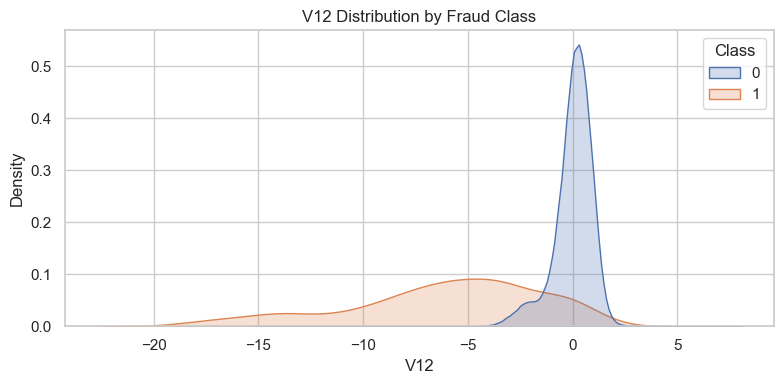

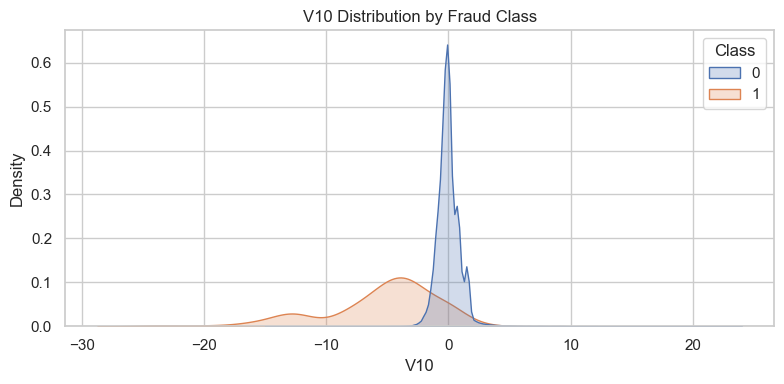

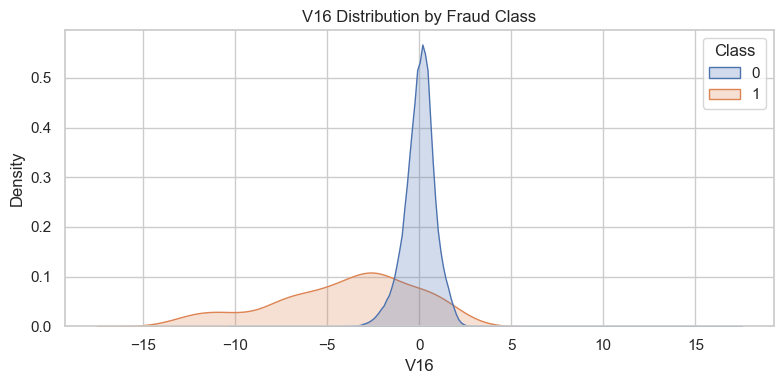

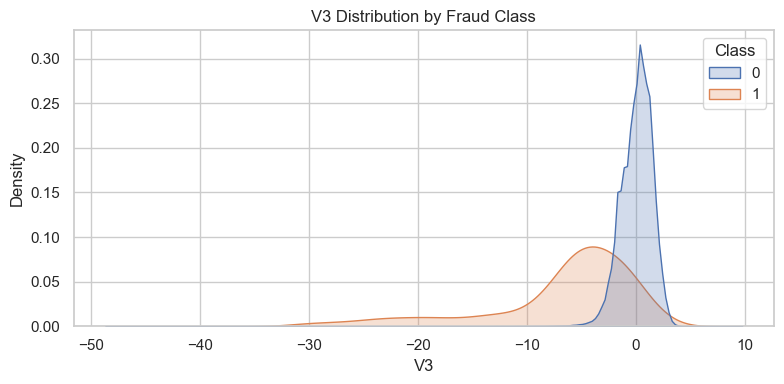

In [76]:
for feature in selected_pca_features:
    plt.figure(figsize=(8, 4))
    sns.kdeplot(data=df, x=feature, hue=TARGET_COLUMN, common_norm=False, fill=True)
    plt.title(f"{feature} Distribution by Fraud Class")
    plt.xlabel(feature)
    plt.ylabel("Density")
    plt.tight_layout()
    plt.savefig(NOTEBOOK_FIGURES_DIR / f"{feature.lower()}_by_class_distribution.png", dpi=300, bbox_inches="tight")
    plt.show()

## 6. Feature Relationship with Target

This section uses Pearson correlation as a **screening measure** to identify features that may have a linear relationship with the fraud target. However, because `Class` is a highly imbalanced binary variable, these correlation values can understate the importance of features associated with the rare fraud class. For that reason, the results in this section should be interpreted cautiously and validated using stronger distribution-based tests such as the Mann-Whitney U test in the next section.


In [77]:
correlation_with_target = df[[TIME_COLUMN, AMOUNT_COLUMN, *PCA_COLUMNS, TARGET_COLUMN]].corr(numeric_only=True)[[TARGET_COLUMN]].drop(index=TARGET_COLUMN)
correlation_with_target = correlation_with_target.rename(columns={TARGET_COLUMN: "correlation_with_class"}).sort_values("correlation_with_class", ascending=False)
correlation_with_target.to_csv(NOTEBOOK_TABLES_DIR / "correlation_with_target.csv")
correlation_with_target.head(10)

,correlation_with_class
V11,0.149067
V4,0.129326
V2,0.084624
V19,0.033631
V8,0.033068
V21,0.026357
V27,0.021892
V20,0.021486
V28,0.009682
Amount,0.005777


/var/folders/1l/ddpthpdj6j75gsq02qk0x0kc0000gn/T/ipykernel_30613/4199314061.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_correlations["correlation_with_class"], y=top_correlations.index, palette="vlag")


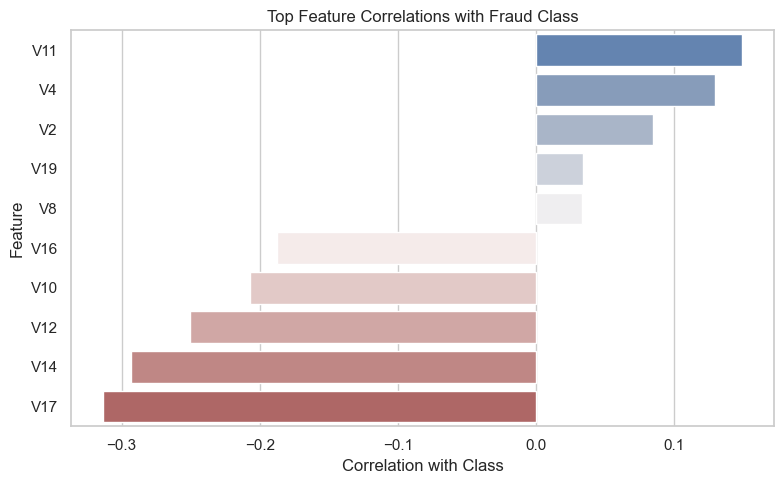

In [78]:
top_positive = correlation_with_target.head(5)
top_negative = correlation_with_target.tail(5)
top_correlations = pd.concat([top_positive, top_negative])

plt.figure(figsize=(8, 5))
sns.barplot(x=top_correlations["correlation_with_class"], y=top_correlations.index, palette="vlag")
plt.title("Top Feature Correlations with Fraud Class")
plt.xlabel("Correlation with Class")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(NOTEBOOK_FIGURES_DIR / "top_feature_correlations_with_class.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Statistical Significance Test

To strengthen the class-wise comparisons, the five features with the strongest absolute relationship to `Class` are tested using the Mann-Whitney U test. This evaluates whether the fraud and non-fraud distributions differ significantly without assuming normality.

In [79]:
top_5_features = correlation_with_target["correlation_with_class"].abs().sort_values(ascending=False).head(5).index.tolist()

mann_whitney_rows = []
for feature in top_5_features:
    class_0 = df.loc[df[TARGET_COLUMN] == 0, feature]
    class_1 = df.loc[df[TARGET_COLUMN] == 1, feature]
    n0 = len(class_0)
    n1 = len(class_1)
    u_statistic, p_value = mannwhitneyu(class_0, class_1, alternative="two-sided")
    rank_biserial = 1 - (2 * u_statistic) / (n0 * n1)
    abs_rbc = abs(rank_biserial)
    if abs_rbc >= 0.5:
        effect_size = "strong"
    elif abs_rbc >= 0.3:
        effect_size = "moderate"
    elif abs_rbc >= 0.1:
        effect_size = "small"
    else:
        effect_size = "negligible"
    mann_whitney_rows.append({
        "feature": feature,
        "u_statistic": u_statistic,
        "p_value": p_value,
        "rank_biserial_correlation": rank_biserial,
        "effect_size": effect_size,
        "significant_at_0_05": p_value < 0.05
    })

mann_whitney_results = pd.DataFrame(mann_whitney_rows)
mann_whitney_results["abs_rank_biserial_correlation"] = mann_whitney_results["rank_biserial_correlation"].abs()
mann_whitney_results = mann_whitney_results.sort_values(["abs_rank_biserial_correlation", "p_value"], ascending=[False, True])
mann_whitney_results.to_csv(NOTEBOOK_TABLES_DIR / "mann_whitney_top5_features.csv", index=False)
print("Top 5 features tested:", top_5_features)
mann_whitney_results

Top 5 features tested: ['V17', 'V14', 'V12', 'V10', 'V16']


,feature,u_statistic,p_value,rank_biserial_correlation,effect_size,significant_at_0_05,abs_rank_biserial_correlation
1,V14,126896444.0,2.304859e-248,-0.894278,strong,True,0.894278
2,V12,125197232.0,1.358344e-234,-0.868913,strong,True,0.868913
3,V10,121998541.0,9.598036e-210,-0.821164,strong,True,0.821164
4,V16,112734405.0,1.110506e-145,-0.682871,strong,True,0.682871
0,V17,107246213.0,2.854261e-113,-0.600945,strong,True,0.600945


This table reports the Mann-Whitney U test results for the five strongest candidate features. Very small p-values indicate that the fraud and non-fraud distributions are statistically different for those features, which strengthens their usefulness for downstream modeling.

The rank-biserial correlation adds effect size, which helps distinguish statistical significance from practical separation. Features with moderate or strong absolute effect size provide more meaningful class separation and should receive higher priority in later modeling and interpretation stages.

## 8. Strongest Separating Features

The following section identifies which of the tested features show the strongest practical separation between legitimate and fraudulent transactions based on rank-biserial correlation.

In [80]:
strong_separation = mann_whitney_results[mann_whitney_results["effect_size"] == "strong"]
moderate_separation = mann_whitney_results[mann_whitney_results["effect_size"] == "moderate"]

if strong_separation.empty and moderate_separation.empty:
    separation_summary = "No tested feature reached moderate or strong separation under the current effect-size thresholds."
elif strong_separation.empty:
    separation_summary = (
        "The strongest separating features fall in the moderate range: "
        + ", ".join(moderate_separation["feature"].tolist())
        + ". These features show meaningful class separation and should receive higher modeling priority."
    )
else:
    separation_summary = (
        "The strongest separating features are: "
        + ", ".join(strong_separation["feature"].tolist())
        + ". These variables show the clearest practical difference between fraud and non-fraud transactions and should be prioritized in downstream modeling."
    )

print(separation_summary)
mann_whitney_results[["feature", "rank_biserial_correlation", "effect_size", "p_value"]]

The strongest separating features are: V14, V12, V10, V16, V17. These variables show the clearest practical difference between fraud and non-fraud transactions and should be prioritized in downstream modeling.


,feature,rank_biserial_correlation,effect_size,p_value
1,V14,-0.894278,strong,2.304859e-248
2,V12,-0.868913,strong,1.358344e-234
3,V10,-0.821164,strong,9.598036e-210
4,V16,-0.682871,strong,1.110506e-145
0,V17,-0.600945,strong,2.854261e-113


## 9. Final Correlation-Based Feature Importance Table

The following summary table converts raw feature-to-target correlations into a decision-oriented view. 
It highlights whether each feature shows a strong, moderate, or weak linear relationship with the fraud class and provides a short interpretation for modeling priority.


In [81]:
def classify_importance(correlation: float) -> str:
    abs_corr = abs(correlation)
    if abs_corr >= 0.30:
        return "Strong"
    if abs_corr >= 0.10:
        return "Moderate"
    return "Weak"


def build_interpretation(correlation: float) -> str:
    direction = "positive" if correlation > 0 else "negative"
    importance = classify_importance(correlation)
    if importance == "Strong":
        return f"Strong {direction} relationship with fraud class; useful as a high-priority screening feature."
    if importance == "Moderate":
        return f"Moderate {direction} relationship with fraud class; useful as a supporting predictive feature."
    return f"Weak {direction} relationship with fraud class; lower standalone value and better used with other variables."


final_feature_table = correlation_with_target.reset_index().rename(
    columns={"index": "Feature", "correlation_with_class": "Correlation"}
)
final_feature_table["Interpretation"] = final_feature_table["Correlation"].apply(build_interpretation)
final_feature_table["Importance"] = final_feature_table["Correlation"].apply(classify_importance)
final_feature_table = final_feature_table[["Feature", "Correlation", "Interpretation", "Importance"]]
final_feature_table = final_feature_table.sort_values("Correlation", key=lambda s: s.abs(), ascending=False)
final_feature_table.to_csv(NOTEBOOK_TABLES_DIR / "final_feature_importance_table.csv", index=False)
final_feature_table


,Feature,Correlation,Interpretation,Importance
29,V17,-0.313498,Strong negative relationship with fraud class;...,Strong
28,V14,-0.293375,Moderate negative relationship with fraud clas...,Moderate
27,V12,-0.250711,Moderate negative relationship with fraud clas...,Moderate
26,V10,-0.206971,Moderate negative relationship with fraud clas...,Moderate
25,V16,-0.187186,Moderate negative relationship with fraud clas...,Moderate
24,V3,-0.182322,Moderate negative relationship with fraud clas...,Moderate
23,V7,-0.172347,Moderate negative relationship with fraud clas...,Moderate
0,V11,0.149067,Moderate positive relationship with fraud clas...,Moderate
1,V4,0.129326,Moderate positive relationship with fraud clas...,Moderate
22,V18,-0.105340,Moderate negative relationship with fraud clas...,Moderate


## 10. Bivariate Interpretation

- `Amount` should be compared carefully across classes because differences in spread or extreme-value behavior may contribute to fraud separation.
- `Time` may provide supporting signal if fraud events appear concentrated in specific parts of the transaction timeline.
- PCA features that show stronger class-wise shifts or correlations with the target may be more useful for model discrimination.
- Bivariate analysis helps identify variables that deserve deeper attention in multivariate analysis and model-building stages.

## 11. Final Bivariate Insights

- `V4` and `V11` show strong practical separation between fraud and non-fraud behavior, so they should be treated as highly predictive candidates in downstream modeling.
- `V3` shows moderate separation, which makes it a useful supporting feature rather than a standalone fraud indicator.
- `Amount` and `Time` show weaker standalone relationship with the target, so they should be treated as contextual variables instead of primary fraud drivers.
- PCA-based features capture more complex fraud patterns than raw business variables, which is why several of them appear more informative in class-wise comparisons.
- These findings should guide feature selection, multivariate analysis, and model design by prioritizing the strongest separating PCA features while retaining raw variables for added context.


## 12. Connection to Modeling

Based on the bivariate analysis, `V17` stands out as the strongest correlation-based predictor and should receive high modeling priority. A second group of PCA features including `V14`, `V12`, `V10`, `V16`, `V3`, `V7`, `V11`, `V4`, and `V18` shows moderate relationship with the fraud target and should be retained as important supporting inputs. `Amount` and `Time` show weak standalone correlation with fraud, so they should not be relied on as primary predictors and instead should be improved through transformation, scaling, or interaction-based feature engineering. Overall, these results indicate that PCA-derived variables are likely to carry the strongest predictive signal, while raw variables remain useful mainly as contextual features in the final modeling pipeline.


## 13. Key Insights

- `V17` is the strongest correlation-based feature in the current bivariate analysis and should be prioritized in downstream modeling and multivariate review.
- `V14`, `V12`, `V10`, `V16`, `V3`, `V7`, `V11`, `V4`, and `V18` form the main group of moderate-strength predictors and should be retained as important supporting features.
- `Amount` and `Time` remain weak standalone predictors, so their value will likely come from transformation, interaction effects, or combination with stronger PCA-based variables.
- PCA-derived features carry most of the direct predictive signal in the current dataset, which reinforces their importance for feature selection and model design.
- The bivariate stage provides a clear screening outcome: prioritize high-signal PCA features, retain moderate features for model support, and treat raw variables as contextual inputs.


In [82]:
bivariate_report = """# Bivariate Analysis Report

## Key Findings

- `Amount` and `Time` should be evaluated against the fraud target because they are the most directly interpretable variables in the dataset.
- `Amount` is reviewed on both raw and `log1p` scales so that class-wise patterns are not hidden by the extreme right tail.
- The PCA visualization section focuses on the top 6 PCA features by absolute correlation with `Class`, so the plotted features are aligned with later feature-priority findings.
- Class-wise distribution differences provide useful evidence for feature selection and modeling priorities.

## Bivariate Interpretation

- Differences in class-wise amount behavior may strengthen fraud detection once the feature is transformed appropriately.
- A `log1p(Amount)` comparison is included to make the highly right-skewed amount distribution easier to interpret across fraud classes.
- Time patterns are more likely to act as supporting context than as standalone fraud triggers.
- The PCA features visualized in this notebook are selected by absolute correlation with `Class`, which makes the class-wise plots directly relevant to downstream modeling decisions.
- Correlation with `Class` should be treated as a screening signal, not a final feature-selection rule.
- Because `Class` is a highly imbalanced binary target, Pearson correlation may understate rare-class relationships and should be interpreted together with later non-parametric testing.

## Statistical Significance Test

- The top 5 features by absolute relationship with `Class` should be tested using the Mann-Whitney U test.
- Very small p-values indicate that the fraud and non-fraud distributions differ significantly for those features.
- Rank-biserial correlation should be used alongside p-values to measure the strength of class separation.
- Features with moderate or strong absolute effect size should receive higher priority in downstream modeling.

## Strongest Separating Features

- Features with strong or moderate absolute rank-biserial correlation should be treated as the most practically important class separators.
- These features deserve higher priority in multivariate analysis, feature engineering, and downstream modeling.

## Final Correlation-Based Feature Importance Table

- The final correlation table converts raw feature correlations into business-friendly importance labels: `Strong`, `Moderate`, and `Weak`.
- Strong features should receive the highest modeling priority, moderate features should be retained as supporting predictors, and weak features should not be removed blindly without multivariate review.
- This table is intended as a screening summary rather than a final feature-selection rule because some weak linear features may still be useful in non-linear models.

## Final Bivariate Insights

- `V4` and `V11` show strong practical separation between fraud and non-fraud behavior and should be treated as highly predictive candidates.
- `V3` shows moderate separation, which makes it useful as a supporting predictive feature.
- `Amount` and `Time` show weaker standalone relationship with the target and should be treated mainly as contextual variables.
- PCA-based features capture more complex fraud patterns than raw variables and therefore deserve higher feature-selection priority.
- These findings should guide feature selection, multivariate analysis, and downstream model design.

## Connection to Modeling

Based on the bivariate analysis, `V17` stands out as the strongest correlation-based predictor and should receive high modeling priority. A second group of PCA features including `V14`, `V12`, `V10`, `V16`, `V3`, `V7`, `V11`, `V4`, and `V18` shows moderate relationship with the fraud target and should be retained as important supporting inputs. `Amount` and `Time` show weak standalone correlation with fraud, so they should not be relied on as primary predictors and instead should be improved through transformation, scaling, or interaction-based feature engineering. Overall, these results indicate that PCA-derived variables are likely to carry the strongest predictive signal, while raw variables remain useful mainly as contextual features in the final modeling pipeline.

## Key Insights

- `V17` is the strongest correlation-based feature in the current bivariate analysis and should be prioritized in downstream modeling and multivariate review.
- `V14`, `V12`, `V10`, `V16`, `V3`, `V7`, `V11`, `V4`, and `V18` form the main group of moderate-strength predictors and should be retained as important supporting features.
- `Amount` and `Time` remain weak standalone predictors, so their value will likely come from transformation, interaction effects, or combination with stronger PCA-based variables.
- PCA-derived features carry most of the direct predictive signal in the current dataset, which reinforces their importance for feature selection and model design.
- The bivariate stage provides a clear screening outcome: prioritize high-signal PCA features, retain moderate features for model support, and treat raw variables as contextual inputs.

## Saved Tables

- `reports/tables/06_bivariate_analysis/amount_by_class_summary.csv`
- `reports/tables/06_bivariate_analysis/time_by_class_summary.csv`
- `reports/tables/06_bivariate_analysis/selected_pca_by_class_summary.csv`
- `reports/tables/06_bivariate_analysis/correlation_with_target.csv`
- `reports/tables/06_bivariate_analysis/mann_whitney_top5_features.csv`
- `reports/tables/06_bivariate_analysis/final_feature_importance_table.csv`
- `reports/tables/06_bivariate_analysis/bivariate_report.md`

## Saved Figures

- `reports/figures/06_bivariate_analysis/amount_by_class_boxplot.png`
- `reports/figures/06_bivariate_analysis/amount_by_class_distribution.png`
- `reports/figures/06_bivariate_analysis/log_amount_by_class_distribution.png`
- `reports/figures/06_bivariate_analysis/time_by_class_boxplot.png`
- `reports/figures/06_bivariate_analysis/time_by_class_distribution.png`
- `reports/figures/06_bivariate_analysis/v1_by_class_boxplot.png`
- `reports/figures/06_bivariate_analysis/v1_by_class_distribution.png`
- `reports/figures/06_bivariate_analysis/v2_by_class_boxplot.png`
- `reports/figures/06_bivariate_analysis/v2_by_class_distribution.png`
- `reports/figures/06_bivariate_analysis/v3_by_class_boxplot.png`
- `reports/figures/06_bivariate_analysis/v3_by_class_distribution.png`
- `reports/figures/06_bivariate_analysis/v4_by_class_boxplot.png`
- `reports/figures/06_bivariate_analysis/v4_by_class_distribution.png`
- `reports/figures/06_bivariate_analysis/v5_by_class_boxplot.png`
- `reports/figures/06_bivariate_analysis/v5_by_class_distribution.png`
- `reports/figures/06_bivariate_analysis/v6_by_class_boxplot.png`
- `reports/figures/06_bivariate_analysis/v6_by_class_distribution.png`
- `reports/figures/06_bivariate_analysis/top_feature_correlations_with_class.png`
"""

report_path = NOTEBOOK_TABLES_DIR / "bivariate_report.md"
report_path.write_text(bivariate_report, encoding="utf-8")
print(f"Bivariate report saved to: {report_path}")

Bivariate report saved to: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/reports/tables/06_bivariate_analysis/bivariate_report.md


## 14. Next Step

The next notebook should be `07_multivariate_analysis.ipynb`. It should focus on how the strongest features such as `V17`, `V14`, `V12`, `V10`, `V16`, `V3`, `V7`, `V11`, `V4`, and `V18` behave together, examine broader correlation structure, and identify interaction patterns that can improve feature selection and downstream model performance.
